# 06 — Layer 3: Integrated Risk Modelling (Stress Testing & IFRS 9 ECL)

NB01 set out a three-layer credit risk architecture, and the pipeline has been building toward this notebook ever since:

* **Layer 1 — Micro-Level Credit Risk:** the borrower-level default model trained on LendingClub loan data — features engineered in NB03, champion selected and calibrated in NB04, and explained with SHAP in NB05.
* **Layer 2 — Macroeconomic Risk:** Canadian economic conditions — interest rates, unemployment, inflation, household debt stress, and insolvency generated in NB1 and its trends — characterised in the macro analysis of NB02.
* **Layer 3 — Integrated Risk Modelling:** combining the two to assess how individual credit risk behaves as economic conditions change.

This notebook *is* Layer 3. Layers 1 and 2 were built separately and deliberately never joined at the loan level; they meet here, at the portfolio, where the borrower-level PDs and the macroeconomic scenarios are integrated into a single forward-looking provisioning view. The vehicle for that integration is the IFRS 9 Expected Credit Loss (ECL) allowance — the figure a lender must actually hold against its book.

The integration proceeds in three steps, each drawing a layer forward:

1. **Score the portfolio (Layer 1 → here).** Apply the calibrated champion to the held-out portfolio to obtain borrower-level probabilities of default.
2. **Size the baseline allowance (IFRS 9 ECL).** Stage the loans, apply LGD and EAD, and compute the expected credit loss the portfolio carries today.
3. **Overlay macroeconomic stress (Layer 2 → here).** Translate the macro layer into unemployment-shock scenarios and re-compute ECL under each, producing the provisioning table a risk committee reviews.

A note on the PDs feeding this notebook: the champion's class-weighted training inflates its raw probabilities (validation Brier exceeded the base rate), so they rank-order risk well but are not usable as dollar-weighted PDs until recalibrated. NB04 recalibrated the champion (isotonic) on the validation set, so the PDs loaded here are calibrated estimates suitable for multiplying into a loss allowance. The LGD, lifetime, SICR, and elasticity figures below are stated assumptions a lender would calibrate to its own loss history; the structure is the one IFRS 9 requires.

In [1]:
import os

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

plt.rcParams['figure.dpi'] = 110
print('successful')

successful


## 1. Score the portfolio with the calibrated champion

We load the calibrated champion and the held-out production test set (the 2017–2018 vintages, never seen during training or calibration) and score each loan. Two checks run before any provisioning is computed:

* **Right artifact:** re-printing the test AUC confirms the loaded model is the production champion, not a stale file.
* **Calibration:** the mean calibrated PD should sit close to the observed default rate. ECL multiplies PDs by dollars, so a model that ranks well but runs systematically hot or cold would mis-size the allowance even with perfect discrimination. This single comparison is what justifies using these PDs as dollar weights.

The structural asserts (matching row counts, positive non-null exposures, PDs inside [0, 1]) are the conditions every later cell silently relies on, so they are enforced here once, loudly.

In [2]:
# Calibrated champion from NB04 (isotonic-recalibrated XGBoost)
champion = joblib.load(f'../models/champion_xgb_calibrated.pkl')

# Held-out production test set [2017-2018]
X_test = pd.read_parquet(f'../data/processed/X_test.parquet')
y_test = pd.read_parquet(f'../data/processed/y_test.parquet').squeeze()

# Structural checks every later cell relies on
assert len(X_test) == len(y_test), 'Feature and label row counts differ'
assert 'loan_amnt' in X_test.columns, 'loan_amnt missing'
assert X_test['loan_amnt'].notna().all(), 'loan_amnt contains nulls'
assert (X_test['loan_amnt'] > 0).all(), 'loan_amnt must be positive'

pd_12m = champion.predict_proba(X_test)[:,1]
assert ((pd_12m >= 0) & (pd_12m <=1)).all(), 'PDs outside [0, 1]'

print(f'Test loans scored       : {len(X_test):,}')
print(f'Test AUC (sanity check) : {roc_auc_score(y_test, pd_12m):.4f}')
print(f'Mean calibrated PD      : {pd_12m.mean():.4f}')
print(f'Observed default rate   : {y_test.mean():.4f}')

Test loans scored       : 16,772
Test AUC (sanity check) : 0.6656
Mean calibrated PD      : 0.2205
Observed default rate   : 0.2129


## 2 — IFRS 9 Expected Credit Loss (ECL) Framework

The purpose of this step is to convert model outputs into a quantity that is meaningful to a lender: the **expected provision for credit losses**. While the previous step focused on predicting default risk, IFRS 9 requires lenders to translate that risk into an expected monetary loss.

**Expected Credit Loss (ECL)** is calculated as:

> **ECL = PD × LGD × EAD**

where:

- **PD (Probability of Default)** is the calibrated, origination-time probability of default generated by the champion model.
- **LGD (Loss Given Default)** is assumed to be **45%**, reflecting a typical unsecured consumer lending portfolio.
- **EAD (Exposure at Default)** is proxied by the loan amount.

### IFRS 9 Staging

IFRS 9 requires provisions to scale with credit deterioration: performing loans carry a 12-month ECL, while loans showing significantly increased risk or actual impairment carry a lifetime ECL.

| Stage | What it means in this study | ECL Horizon |
|---------|---------|---------|
| **Stage 1** | Performing loans with calibrated PDs below the SICR threshold. These borrowers are considered relatively low risk, so the provision covers only defaults expected within the next 12 months. | **12-month ECL** |
| **Stage 2** | Performing loans whose calibrated PD falls within the **riskiest 20% of the portfolio** (above the 80th-percentile threshold). This is used as a practical proxy for a significant increase in credit risk (SICR), since the origination-time PD model does not support the standard IFRS 9 relative-deterioration test. | **Lifetime ECL** |
| **Stage 3** | Loans with a realised default, treated as credit-impaired exposures. For these loans, **PD is set to 100%**, meaning ECL simplifies to **LGD × EAD**. Because the test vintages are fully resolved, realised defaults can be observed; in a live IFRS 9 implementation, Stage 3 would typically be identified using indicators such as **90+ days past due** rather than known outcomes. | **Lifetime ECL** |


Because Stage 2 exposures require lifetime ECL, and the dataset does not support full lifetime default modelling, **lifetime PD is approximated as 2.5 × the 12-month PD**, capped at 100%. The 2.5× multiplier reflects the portfolio's mix of 36- and 60-month loans. Under a simple flat-hazard assumption, lifetime default risk would be roughly 3–5 times the annual PD over the contractual term. In practice, however, consumer credit defaults are concentrated in the first 9–24 months and many loans are repaid early, reducing their effective life. These effects push the implied multiplier for the dominant 36-month segment closer to 2×, while the smaller population of 60-month loans lifts the portfolio-level approximation to around 2.5×.

### Modelling Assumptions

Two design choices are important for interpreting the results.

#### Stage 3 Identification

Credit-impaired loans are identified using realised default outcomes. This is appropriate because the 2017–2018 test vintages are fully resolved and the final repayment outcome of each loan is known. In a live IFRS 9 environment, lenders would instead rely on observable indicators such as 90+ days past due. This is the only point in the framework where realised outcomes are used; all PD estimates remain based strictly on information available at loan origination.

#### Consistent Baseline and Stress Calculations

Staging and ECL calculations are implemented within a single function, `stage_and_ecl`, which is reused unchanged across the baseline and all stress-testing scenarios. The baseline is simply defined as a zero-shock scenario. Using the same calculation path throughout ensures that any change in provisions can be attributed solely to the applied macroeconomic stress rather than differences in implementation.

### Benchmark Comparison

To provide context for the model-based provisions, a naive flat-rate provision is also calculated. This represents the type of reserve a lender might hold without a risk model, applying the same loss assumption across all borrowers regardless of risk.

This comparison highlights an important point: the ultimate value of a credit risk model is not its AUC or classification accuracy, but its ability to produce more realistic and economically meaningful provisions than a simple one-size-fits-all approach.

In [3]:
# Evidence check: justifying LIFETIME_FACTOR = 2.5
# The lifetime multiplier is a judgement, not a derived constant. This cell grounds it in the actual term mix of the ECL portfolio (X_test).

# 1) Recover loan term for the test portfolio. Origination-time field, used here for a descriptive stat only —
#    it never enters the model or the ECL computation (no leakage).
raw = pd.read_parquet('../data/processed/loans_clean.parquet', columns=['term'])
term_clean = raw.loc[X_test.index, 'term'].str.strip()
term_mix = term_clean.value_counts(normalize=True)
print(term_mix.round(3))

# Sanity check for the 2.5x lifetime PD multiplier.

# These are illustrative, economically motivated assumptions rather than empirically estimated lifetime default curves. The objective is to test
# whether a 2.5x multiplier sits within a plausible range given the portfolio's mix of 36- and 60-month loans.

# Assumptions (haircuts applied to the flat-hazard ceiling of ~3x for 36-month and ~5x for 60-month terms):
# - 36-month loans: effective lifetime PD multiplier of ~2.0–2.2x, reflecting front-loaded default behaviour and early prepayments.
# - 60-month loans: effective lifetime PD multiplier of ~3.5–4.0x, reflecting the longer exposure horizon.

# Test criterion: if 2.5 falls within the blended range, it is a plausible, conservative approximation for this illustrative framework.
seg_low  = term_mix['36 months'] * 2.0 + term_mix['60 months'] * 3.5
seg_high = term_mix['36 months'] * 2.2 + term_mix['60 months'] * 4.0
print(f"Implied blended multiplier range: {seg_low:.2f} – {seg_high:.2f}")
print(f"LIFETIME_FACTOR = 2.5 within range: {seg_low <= 2.5 <= seg_high}")

# 2.5 sits inside the band, toward its upper end — a conservative choice that favours higher provisions over the risk of understating ECL.

term
36 months    0.785
60 months    0.215
Name: proportion, dtype: float64
Implied blended multiplier range: 2.32 – 2.59
LIFETIME_FACTOR = 2.5 within range: True


In [4]:
# Top 20% of baseline PDs => significant increase in credit risk
SICR_QUANTILE = 0.80     

port = pd.DataFrame({
    'pd_12m':     pd_12m,
    'ead':        X_test['loan_amnt'].to_numpy(),
    'is_default': y_test.to_numpy(),
})

# The SICR threshold is fixed on BASELINE PDs and held constant under stress,
# so loans migrate into Stage 2 as scenarios deteriorate (Step 3).
SICR_THRESHOLD = port['pd_12m'].quantile(SICR_QUANTILE)
print(f'SICR threshold (80th-percentile baseline PD): {SICR_THRESHOLD:.4f}')
print()
print(port.head())

SICR threshold (80th-percentile baseline PD): 0.3064

     pd_12m      ead  is_default
0  0.075728   7000.0           0
1  0.238604  40000.0           0
2  0.142857  10000.0           0
3  0.284038  16000.0           0
4  0.163043  10000.0           0


In [5]:
# Stated assumptions (a lender would calibrate these to internal loss history) 
LGD = 0.45               # loss given default, unsecured consumer credit
LIFETIME_FACTOR = 2.5    # stylised lifetime PD multiplier for IFRS 9 ECL

# Define IFRS 9 staging and ECL function
def stage_and_ecl(pd_12m_vec, ead, defaulted):
    """IFRS 9 staging and ECL for a vector of 12-month PDs.

    Stage 3: credit-impaired (realised defaults proxy impairment here) -> PD = 1
    Stage 2: PD at or above the fixed SICR threshold -> lifetime ECL
    Stage 1: everything else -> 12-month ECL
    """
    # IFRS 9 staging:
    stage = np.select([defaulted == 1, pd_12m_vec >= SICR_THRESHOLD],[3, 2],default=1,)
    
    # Select the appropriate PD horizon: 
    # Stage 1 -> 12-month PD. Stage 2 -> approximated lifetime PD
    pd_used = np.where(stage == 1, pd_12m_vec, np.minimum(1.0, pd_12m_vec * LIFETIME_FACTOR))
    
    # Stage 3  -> loans already defaulted, so PD is set to 100%
    pd_used = np.where(stage == 3, 1.0, pd_used)   # already defaulted


    # IFRS 9 Expected Credit Loss: ECL = PD × LGD × EAD
    ecl = pd_used * LGD * ead
    return stage, ecl

In [6]:
# Apply IFRS 9 staging and calculate loan-level ECL
port['stage'], port['ecl'] = stage_and_ecl(
    port['pd_12m'].to_numpy(),
    port['ead'].to_numpy(),
    port['is_default'].to_numpy()
)

# Stage-level summary
stage_summary = pd.DataFrame()

stage_summary['loans'] = port.groupby('stage').size()
stage_summary['exposure'] = port.groupby('stage')['ead'].sum()
stage_summary['ecl'] = port.groupby('stage')['ecl'].sum()
stage_summary['coverage_%'] = (stage_summary['ecl'] / stage_summary['exposure']* 100)

# Descriptive stage labels
stage_summary.index = [
    'Stage 1 - Performing',
    'Stage 2 - SICR',
    'Stage 3 - Credit Impaired'
]

print('\nBaseline ECL by IFRS 9 stage:')
print(stage_summary.to_string(formatters={
    'loans':      '{:,.0f}'.format,
    'exposure':   '${:,.0f}'.format,
    'ecl':        '${:,.0f}'.format,
    'coverage_%': '{:.2f}'.format,
}))



# Portfolio-level summary
baseline_ecl = port['ecl'].sum()
portfolio_ead = port['ead'].sum()
coverage_ratio = 100 * baseline_ecl / portfolio_ead

print(f'\nTotal baseline ECL : ${baseline_ecl:,.0f}')
print(f'Portfolio EAD      : ${portfolio_ead:,.0f}')
print(f'Coverage ratio     : {coverage_ratio:.2f}%')


Baseline ECL by IFRS 9 stage:
                           loans     exposure         ecl coverage_%
Stage 1 - Performing      10,687 $135,450,375 $10,828,689       7.99
Stage 2 - SICR             2,514  $50,454,125 $20,708,922      41.05
Stage 3 - Credit Impaired  3,571  $56,212,200 $25,295,490      45.00

Total baseline ECL : $56,833,101
Portfolio EAD      : $242,116,700
Coverage ratio     : 23.47%


### The Value of the PD Model in Monetary Terms

A lender without a credit risk model would typically apply a single portfolio-average provision rate across all loans. While this approach may produce a similar total provision at the portfolio level, it implicitly assumes that every borrower carries the same level of risk. In reality, credit risk varies significantly across borrowers: some are unlikely to default, while others present a materially higher probability of loss.

The PD model enables this risk differentiation. By estimating borrower-level default probabilities, the model supports IFRS 9 staging and allows provisions to be aligned with the underlying risk of each exposure. Lower-risk loans remain in **Stage 1** and attract a **12-month ECL**, while borrowers identified as experiencing a **Significant Increase in Credit Risk (SICR)** are transferred to **Stage 2** and provisioned on a **lifetime ECL** basis. Credit-impaired exposures are assigned to **Stage 3**, where the probability of default is treated as **100%** and the provision effectively becomes **LGD × EAD**.

The stage-level results demonstrate this risk sensitivity. Provision coverage rises substantially from Stage 1 to Stage 3, reflecting the progressive deterioration in credit quality across the portfolio. This graduated treatment is something a flat-rate approach cannot achieve. Under a uniform provision rate, low-risk borrowers would be over-provisioned, high-risk borrowers would be under-provisioned, and credit-impaired exposures would be treated no differently from performing loans.

The comparison below therefore measures the practical value of the model. The objective is not simply to achieve a higher AUC or stronger classification metrics, but to produce more economically meaningful provisions. In business terms, the model's value lies in directing capital toward the loans most likely to generate losses while avoiding unnecessary provisioning on lower-risk exposures. The difference between the model-based and flat-rate approaches quantifies that value in dollar terms.

In [7]:
# Reference point: a flat-rate provision with no risk model
NAIVE_PD = port['is_default'].mean()      # one flat PD applied to every loan
naive_ecl = NAIVE_PD * LGD * portfolio_ead

print(f'Naive flat-rate ECL : ${naive_ecl:,.0f}  (PD = {NAIVE_PD:.3f} on every loan)')
print(f'Model-based ECL     : ${baseline_ecl:,.0f}')
print(f'Difference          : ${baseline_ecl - naive_ecl:,.0f}  ' f'({100 * (baseline_ecl / naive_ecl - 1):+.1f}%)')

Naive flat-rate ECL : $23,197,557  (PD = 0.213 on every loan)
Model-based ECL     : $56,833,101
Difference          : $33,635,544  (+145.0%)


## 3 — Macro stress overlay

Finally we propagate macroeconomic stress into provisions. Three scenarios are defined as unemployment shocks above baseline, broadly aligned with the severity steps in the Bank of Canada's Financial System Review stress framework:

| Scenario | Unemployment shock |
|---|---|
| Baseline | +0.0 pp |
| Adverse | +2.0 pp |
| Severely Adverse | +4.5 pp |

A simple elasticity links unemployment to default: each percentage point of unemployment shock raises every loan's PD by 10% relative. Because the SICR threshold stays fixed at its baseline value, stress moves loans across it — the Stage 2 count grows under each scenario. ECL therefore rises through two channels at once: every loan's PD lifts, *and* migrating loans switch from 12-month to lifetime ECL. That second, migration-driven channel is what makes the provisioning response non-linear, and it is the behaviour IFRS 9's point-in-time staging is designed to capture.

Each scenario is just `stage_and_ecl` applied to shocked PDs; the baseline row doubles as a regression check against Step 2.

In [8]:
# Grounding the scenario shocks in Canadian macro history (Layer 2)
# The macro panel is used at aggregate level only — scenario design, never row-level joins to loan data (per the pipeline's leakage rules).

macro = pd.read_parquet('../data/processed/macro_panel.parquet')

macro['date'] = pd.to_datetime(macro['date'])
macro = macro.set_index('date').sort_index()
u = macro['unemployment_rate']            # re-point u at the re-indexed frame

pre_covid = u[u.index < '2020-01-01']
print(f"Largest 12-month increase pre-COVID: +{pre_covid.diff(12).max():.1f}pp")

gfc = u['2008-01-01':'2010-12-31']
print(f"GFC trough-to-peak: {gfc.min():.1f}% → {gfc.max():.1f}% (+{gfc.max()-gfc.min():.1f}pp)")

Largest 12-month increase pre-COVID: +2.7pp
GFC trough-to-peak: 6.1% → 8.8% (+2.7pp)


### Why +2.7pp and +4.5pp?

The shock magnitudes are anchored directly in the Layer 2 Canadian macro panel. The **adverse scenario (+2.7pp) replays the 2008–09 GFC exactly** —
the largest sustained unemployment increase in the 26-year panel (6.1% → 8.8% trough-to-peak). The COVID spike (+8.7pp) was larger but
artificial and rapidly reversed, making it a poor template for sustained credit stress. The **severely adverse scenario (+4.5pp) is deliberately
beyond-sample** at roughly 1.7× the worst observed episode — consistent with regulatory severe-scenario design, which requires stress beyond
historical experience.
The panel informs scenario *design* only; no macro series is ever joined to loan-level data.

In [9]:
SHOCKS = {
    'Baseline':         0.0,   # current conditions, no shock
    'Adverse':          2.7,   # exact replay of the GFC, the largest sustained
                               # unemployment shock in the 26-yr Layer 2 panel
    'Severely Adverse': 4.5,   # ~1.7x the worst observed episode — deliberately
                               # beyond-sample, per regulatory severe design
}
PD_ELASTICITY = 0.10   # +10% relative PD per +1pp unemployment shock (assumption)

rows = []
for name, shock_pp in SHOCKS.items():
    shocked_pd = np.minimum(1.0, port['pd_12m'].to_numpy() * (1 + PD_ELASTICITY * shock_pp))
    stage, ecl = stage_and_ecl(shocked_pd, port['ead'].to_numpy(), port['is_default'].to_numpy())
    rows.append({
        'Scenario':         name,
        'Unemp shock (pp)': shock_pp,
        'Total ECL ($)':    ecl.sum(),
        'Coverage (%)':     100 * ecl.sum() / portfolio_ead,
        'Stage 2 loans':    int((stage == 2).sum()),
        'Stage 3 loans':    int((stage == 3).sum()),
    })

provisions = pd.DataFrame(rows)
provisions['ECL vs baseline (%)'] = 100 * (provisions['Total ECL ($)'] / baseline_ecl - 1)

# The zero-shock scenario must reproduce the Step 2 baseline exactly
assert np.isclose(provisions.loc[0, 'Total ECL ($)'], baseline_ecl), \
    'Baseline scenario does not match Step 2 ECL'

print(provisions.to_string(index=False, formatters={
    'Total ECL ($)':       '${:,.0f}'.format,
    'Coverage (%)':        '{:.2f}'.format,
    'Stage 2 loans':       '{:,}'.format,
    'Stage 3 loans':       '{:,}'.format,
    'ECL vs baseline (%)': '{:+.1f}'.format,
}))

        Scenario  Unemp shock (pp) Total ECL ($) Coverage (%) Stage 2 loans Stage 3 loans ECL vs baseline (%)
        Baseline               0.0   $56,833,101        23.47         2,514         3,571                +0.0
         Adverse               2.7   $65,636,032        27.11         3,537         3,571               +15.5
Severely Adverse               4.5   $73,333,368        30.29         5,022         3,571               +29.0


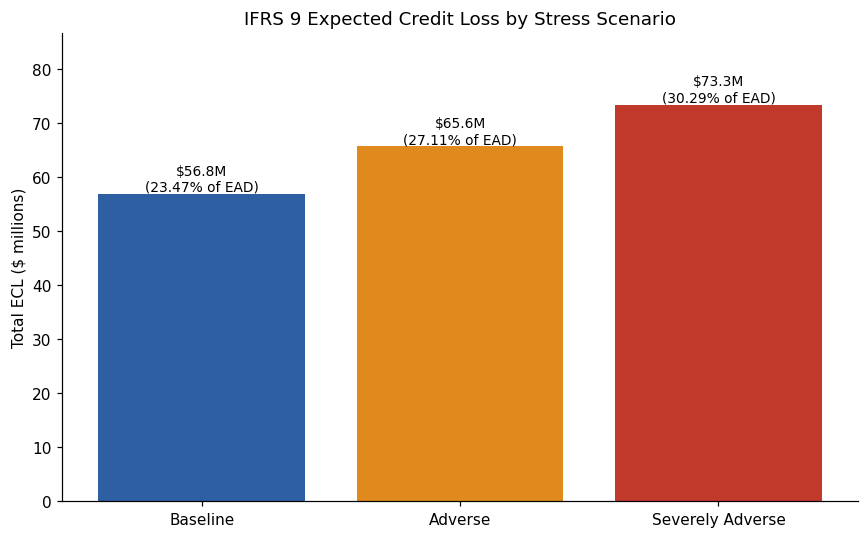

In [10]:
# Visualise the provisioning impact

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(provisions['Scenario'], provisions['Total ECL ($)'] / 1e6,
              color=['#2E5FA3', '#E08A1E', '#C0392B'])

for bar, total, cov in zip(bars, provisions['Total ECL ($)'], provisions['Coverage (%)']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'${total / 1e6:,.1f}M\n({cov:.2f}% of EAD)',
            ha='center', va='bottom', fontsize=9)

ax.set_title('IFRS 9 Expected Credit Loss by Stress Scenario')
ax.set_ylabel('Total ECL ($ millions)')
ax.set_ylim(0, provisions['Total ECL ($)'].max() / 1e6 * 1.18)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'../report/figures/ecl_01_provisions.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

This stress-testing exercise demonstrates how borrower-level credit risk estimates can be translated into IFRS 9 provisions under alternative macroeconomic scenarios. Three metrics are particularly important when assessing the results: **coverage ratio**, **stage migration**, and **ECL uplift**.

Portfolio coverage increases from **23.5%** of EAD under the baseline scenario to **30.3%** under the severely adverse scenario, reflecting the higher expected losses generated by stressed probabilities of default. The absolute level of coverage should be interpreted with caution because the 2017–2018 test vintages are fully resolved and contain **3,571 realised defaults** provisioned at **LGD × EAD**. Consequently, the change in coverage across scenarios is more informative than the level itself.

The increase in provisions is driven primarily by **Stage 1-to-Stage 2 migration**. Under the baseline scenario, **2,514 loans** are classified as Stage 2, while under the severely adverse scenario this rises to **5,022 loans**, meaning the population subject to lifetime ECL approximately doubles. Stage 3 remains fixed at **3,571 loans** because impairment is determined by realised default status, which is unaffected by the stress scenarios. As a result, deteriorating economic conditions increase provisions mainly by pushing additional performing loans above the SICR threshold and into lifetime loss recognition.

The most direct measure of stress impact is the uplift in expected credit losses relative to the baseline scenario. Portfolio ECL increases by approximately **$8.8 million (+15.5%)** under the adverse scenario and **$16.5 million (+29.0%)** under the severely adverse scenario. From a risk-management perspective, these figures quantify the additional allowance that would be required if economic conditions deteriorated as assumed.

The stress response is broadly proportional to the size of the macroeconomic shock. This behaviour is expected because the framework applies a constant PD elasticity to unemployment shocks, creating an approximately linear relationship between economic deterioration and expected credit losses. In practice, credit losses often exhibit non-linear behaviour during severe downturns as borrower distress and default rates accelerate. Consequently, the severe-scenario results should be viewed as a conservative illustration rather than a fully calibrated estimate of recessionary losses.

More broadly, the exercise closes the loop from **model development to business decision-making**. The calibrated PD model supplies borrower-level default probabilities, the stress scenarios define plausible economic deterioration paths, and the IFRS 9 framework converts both into the provisions that drive financial reporting, capital planning, and risk management decisions. The value of the model is therefore not simply its predictive performance, but its ability to allocate provisions according to risk, identify significant increases in credit risk, and provide a forward-looking assessment of potential portfolio losses.